In [1]:
import pandas as pd

# Data Cleaning Project

## Objective

The objective of this project is to clean a messy sales dataset and prepare it for analysis and machine learning.

In [2]:
original_df = pd.read_csv('Amazon_Messy_Dataset.csv')

df = original_df.copy()

## Dataset

In [3]:
df.head(10)

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,0.00,215.87,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494
6,ORD0000007,2024-09-20,CUST037667,Aarav Verma,P00030,Dress Shirt,Clothing,UrbanStyle,2,219.81,0.20,28.14,14.97,394.81,UPI,Delivered,Chicago,IL,Australia,SELL01676
7,ORD0000008,2022-11-10,CUST031165,Rohit Kumar,P00028,Jeans,Toys & Games,KiddoFun,2,306.51,0.05,29.12,6.24,617.73,Debit Card,Pending,Denver,CO,India,SELL00510
8,ORD0000009,2024-06-26,CUST026965,Aman Kapoor,P00031,Kids Toy Car,Sports & Outdoors,Apex,4,146.09,0.00,46.75,7.03,638.14,Debit Card,Delivered,Washington,DC,United States,SELL01895
9,ORD0000010,2020-05-01,CUST029472,Aarav Reddy,P00001,Wireless Earbuds,Clothing,Apex,2,278.21,0.10,60.09,4.88,565.75,Credit Card,Delivered,Houston,TX,United States,SELL01584


## Step 1 - Data Inspection

First, we inspect the dataset to understand its structure and identify possible data quality issues.## Information About Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   OrderID        100000 non-null  str    
 1   OrderDate      100000 non-null  str    
 2   CustomerID     100000 non-null  str    
 3   CustomerName   100000 non-null  str    
 4   ProductID      100000 non-null  str    
 5   ProductName    100000 non-null  str    
 6   Category       100000 non-null  str    
 7   Brand          100000 non-null  str    
 8   Quantity       100000 non-null  int64  
 9   UnitPrice      100000 non-null  float64
 10  Discount       95000 non-null   float64
 11  Tax            100000 non-null  float64
 12  ShippingCost   100000 non-null  float64
 13  TotalAmount    100000 non-null  float64
 14  PaymentMethod  100000 non-null  str    
 15  OrderStatus    100000 non-null  str    
 16  City           95002 non-null   str    
 17  State          100000 non-null  str    
 

In [5]:
df.describe()

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.000000,100000.000000,95000.000000,100000.000000,100000.000000,100000.000000
mean,3.000180,302.905748,0.074181,68.468902,7.406660,918.256479
std,1.416136,171.840797,0.082569,74.131180,4.324057,724.508332
min,-5.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000


## Observation

- Dataset contains 10,000 rows.
- Two columns have missing values,
 City and Discount columns.
- Order_Date is stored as string.
- Quantity contains negative values.

## Dates Validation

In [6]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'],errors='coerce')

## Dealing with Null Values

In [7]:
df['Discount'] = df['Discount'].fillna(df['Discount'].median())
df['City'] = df['City'].fillna('Unknown')

# Observation  
- city column contains some data which does not contain any name
- The Discount column contains missing values.

Median is chosen because it is less affected by outliers than the mean.


## Duplicated Values

In [8]:
df.duplicated().sum()

np.int64(0)

## Observation

- NOt contain any duplicate values

## Checking  Outliers

<Axes: >

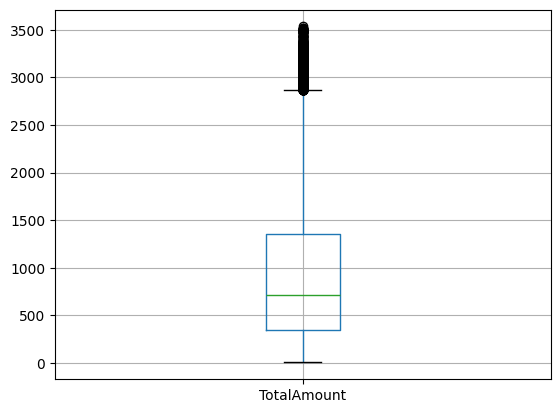

In [9]:
df.boxplot(column='TotalAmount')

In [10]:
df.sort_values("TotalAmount", ascending=False)[["CustomerName",'TotalAmount']].head(10)

,CustomerName,TotalAmount
48442,Anjali Patel,3534.98
81886,Vivaan Joshi,3521.85
4196,Kabir Gupta,3514.24
1929,Pooja Patel,3513.65
58204,Priya Gupta,3513.05
46764,Priya Kapoor,3511.95
40146,Pooja Mehta,3510.23
20578,Sneha Sharma,3509.30
95429,Sunita Joshi,3499.15
51547,Vihaan Gupta,3498.13


## Outlier Detection

### Observation
Outlier analysis was performed using box plots and summary statistics. No unrealistic or invalid values were identified in the numerical columns.

### Decision
No outlier treatment was required, and the data was kept unchanged.

## Customer ID and Customer Name Consistency Check

# 

In [11]:
problem = df.groupby('CustomerID')['CustomerName'].nunique()
problem_ids = problem[problem > 1].index
df[df["CustomerID"].isin(problem_ids)].sort_values("CustomerID")

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
6329,ORD0006330,2020-07-02,CUST000002,Vikas Gupta,P00027,Winter Jacket,Home & Kitchen,FitLife,3,89.46,0.05,20.40,1.90,277.26,Debit Card,Returned,Phoenix,AZ,United States,SELL00886
10090,ORD0010091,2022-02-01,CUST000002,Arjun Singh,P00028,Jeans,Toys & Games,KiddoFun,5,139.70,0.10,50.29,10.46,689.40,Credit Card,Delivered,Los Angeles,CA,United States,SELL01679
40216,ORD0040217,2021-03-31,CUST000002,Ritika Patel,P00046,Car Charger,Toys & Games,KiddoFun,1,427.87,0.10,30.81,7.38,423.27,Credit Card,Delivered,New York,NY,India,SELL01711
22454,ORD0022455,2024-06-17,CUST000004,Karan Kapoor,P00039,Graphic Tablet,Electronics,NexPro,1,592.36,0.10,42.65,7.93,583.70,Credit Card,Shipped,San Diego,CA,Canada,SELL00607
36460,ORD0036461,2023-07-19,CUST000004,Sahil Patel,P00002,Bluetooth Speaker,Electronics,Zenith,4,477.01,0.15,194.62,2.95,1819.40,Amazon Pay,Shipped,Unknown,TX,United States,SELL00170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82559,ORD0082560,2021-05-15,CUST049993,Anjali Kumar,P00018,Vacuum Cleaner,Toys & Games,CoreTech,5,427.96,0.05,243.94,0.41,2277.16,Credit Card,Shipped,Denver,CO,United States,SELL00099
44319,ORD0044320,2023-01-15,CUST049995,Neha Verma,P00024,Yoga Mat,Sports & Outdoors,ReadMore,5,439.68,0.00,175.87,7.80,2382.07,Credit Card,Delivered,Houston,TX,Canada,SELL01026
60012,ORD0060013,2021-12-11,CUST049995,Mohit Kumar,P00031,Kids Toy Car,Books,CoreTech,5,589.83,0.00,235.93,6.17,3191.25,Debit Card,Delivered,Indianapolis,IN,India,SELL00642
77200,ORD0077201,2020-08-12,CUST049997,Aman Kumar,P00048,Wireless Charger,Clothing,NexPro,3,133.01,0.00,71.83,2.21,473.07,UPI,Delivered,Denver,CO,United States,SELL00896


# Observation
Customer Integrity
- One CustomerID maps to multiple CustomerNames.
- Cannot be corrected automatically because no master customer table is available.
- Requires business verification.

## Negative Quantity Validation

In [12]:
df[df["Quantity"] < 0]

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
4549,ORD0004550,2024-02-06,CUST021946,Aditya Kapoor,P00049,Children's Book,Toys & Games,Zenith,-2,576.42,0.05,87.62,6.05,1188.87,Credit Card,Pending,Charlotte,NC,United States,SELL01451
4910,ORD0004911,2020-01-15,CUST022249,Rohit Kumar,P00009,Portable SSD 1TB,Electronics,HomeEase,-3,34.90,0.10,0.00,0.68,94.91,UPI,Delivered,Phoenix,AZ,United States,SELL00032
14045,ORD0014046,2020-04-10,CUST042276,Priya Joshi,P00021,Backpack,Books,NexPro,-3,60.18,0.20,11.55,7.06,163.04,Credit Card,Returned,Seattle,WA,United States,SELL01842
15257,ORD0015258,2022-12-02,CUST040282,Vihaan Verma,P00014,Drone Mini,Sports & Outdoors,BrightLux,-2,173.02,0.05,23.53,0.31,317.97,UPI,Shipped,Philadelphia,PA,United States,SELL00859
21951,ORD0021952,2024-11-24,CUST047051,Neha Reddy,P00047,Memory Card 128GB,Clothing,ReadMore,-5,338.57,0.20,108.34,3.11,1465.73,Net Banking,Delivered,San Antonio,TX,Canada,SELL01132
24034,ORD0024035,2022-07-13,CUST007240,Arjun Patel,P00017,Electric Kettle,Books,CoreTech,-1,376.78,0.05,17.90,1.82,377.66,UPI,Delivered,Washington,DC,United States,SELL00719
31796,ORD0031797,2023-10-13,CUST039971,Aditya Patel,P00002,Bluetooth Speaker,Toys & Games,BrightLux,-5,102.90,0.20,20.58,12.12,444.30,Credit Card,Delivered,Columbus,OH,United States,SELL00239
31980,ORD0031981,2023-06-17,CUST035187,Arjun Reddy,P00006,Gaming Mouse,Books,HomeEase,-1,590.47,0.20,23.62,2.30,498.30,UPI,Delivered,San Jose,CA,India,SELL01760
33059,ORD0033060,2024-05-06,CUST028769,Ritika Verma,P00012,Noise Cancelling Headphones,Toys & Games,HomeEase,-3,473.37,0.15,217.28,14.26,1438.63,Amazon Pay,Delivered,Jacksonville,FL,United Kingdom,SELL00276
34900,ORD0034901,2023-08-28,CUST015500,Vihaan Patel,P00022,Water Bottle,Electronics,KiddoFun,-5,77.42,0.00,30.97,13.58,431.65,Net Banking,Delivered,Los Angeles,CA,United States,SELL00730


In [18]:
df['Quantity'] = df['Quantity'].abs()
df['OrderStatus'].unique()

<StringArray>
['Delivered', 'Cancelled', 'Pending', 'Shipped', 'Returned']
Length: 5, dtype: str

# Observation
Negative Values
- Quantity contains negative values.
- For this learning project, they are treated as data entry mistakes.

## Clean Dataset

In [14]:
df.to_csv('clean_dataset.csv',index=False)

Data Quality Report

1. Missing Values
- Discount contains missing values.
- City contains missing values.

2. Duplicate Rows
- No duplicate rows found.

3. Data Types
- Order_Date converted to datetime successfully.

4. Negative Values
- Quantity contains negative values.
- For this learning project, they are treated as data entry mistakes.

5. Outlier 
- No unrealistic and invalid data find in Total_Amount column

6. Customer Integrity
- One CustomerID maps to multiple CustomerNames.
- Cannot be corrected automatically because no master customer table is available.
- Requires business verification.

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  str           
 1   OrderDate      100000 non-null  datetime64[us]
 2   CustomerID     100000 non-null  str           
 3   CustomerName   100000 non-null  str           
 4   ProductID      100000 non-null  str           
 5   ProductName    100000 non-null  str           
 6   Category       100000 non-null  str           
 7   Brand          100000 non-null  str           
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  str           
 15  OrderStatus 